This Notebook should hopefully walk through how to make a DFN model for a a NCA graphite 1D cell with a 2D thermal model
The method for creating a model in pybam is:
1) Choose the model
2) Select the parameter values
3) Set the discretisation/ meshing
4) Choose the solver and setup model
5) Run Simulartion
5) post process the data

This notebook should lay out these methods individually for each step and explain how it is done

Pre-requisits:
Import all the functions in python needed for pybamm to work.

In [1]:
import pybamm
import matplotlib
import pandas as pd
import numpy as np
import math

c:\ProgramData\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


1) Setup the model:
To set the model you first need to choose what type of model you want to look at for this model we want:
- 1D DFN model to describe the li-ion kinetics
- 2D themal model to describe the temperature

This would make it overal a P2D model as the kinetics are calculated in 1 dimesion.


To create the themal model it needs to be added as a dictionary to the model

In [2]:
options = {"thermal": "lumped"}

The model will then need to call these options

In [3]:
model = pybamm.lithium_ion.DFN(options=options)

2) After this we want to add the parameters for the cell
In this case we will just use chen et al initially.

In [4]:
parameter_values = pybamm.ParameterValues("Chen2020")

3) Discretisation/ meshing
The model has been chosen and the parametes haver been chosen now we need to chose the discretisation e.g time=(0,3600) - this would be the time from 0-3600s with an assumption of 1s timesteps (I think)

you can also use experiment to determine what you want to do as the experimental procedure which will define the opriceduer and the time at which it occurs.

Now we will also add the experiment we want the model to do:

In [5]:
experiment = pybamm.Experiment(
    [
        (
        "Charge at C/2 until 4.2 V",
        "Discharge at C/10 until 2.5 V",
        "Rest for 1 hour",
        )
        ]
    +    [
        (
        "Charge at 1 C until 4.2 V",
        "Hold at 4.2 V until C/10",
        "Rest for 30 minutes",
        "Discharge at C/2 until 2.5 V",
        "Rest for 30 minutes",
        )
    ]*10
)

4. Now we want to solve using a particular solver. In this case we have chosen the CasadiSolver in safe mode which will be more accurate but not as fast, which is the default solver in PyBaMM. 

Safe mode performs step-and-check integration and supports event handling (e.g. you can integrate until you hit a certain voltage), and is the recommended for simulations of a full charge or discharge. Fast mode performs direct integration, ignoring events, and is recommended when simulating a drive cycle or other simulation where no events are triggered.

In [ ]:
safe_solver = pybamm.CasadiSolver(atol=1e-3, rtol=1e-3, mode="safe")

Now the model is set up we want to set up the simulation:

In [ ]:
sim = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment,solver=safe_solver)

5. Run the simulation
Now we have setup the simulation we want to run it. In this case we have specifies 0-3600s but this is egnored because we have dded the experiment.

In [7]:
sim.solve([0, 3600])

2025-04-10 15:36:26.843 - [WARNING] simulation.solve(552): Ignoring t_eval as solution times are specified by the experiment


6. Data Processing
New we have simulated we want to post porocess the data. In this case I am intersted in looking at how the negative potential changes over time and how the temperature changes too.

In [11]:
sim.plot(["Current [A]", "Voltage [V]","Cell temperature [C]",'Negative current collector temperature [C]'], time_unit="minutes")


interactive(children=(FloatSlider(value=0.0, description='t', max=3281.846195642406, step=32.81846195642406), …

This is how to do a 2D plot for example the temperature vs time vs distance

Array of shape (20, 3352) Array of shape (3352, 1) Array of shape (3352, 20)


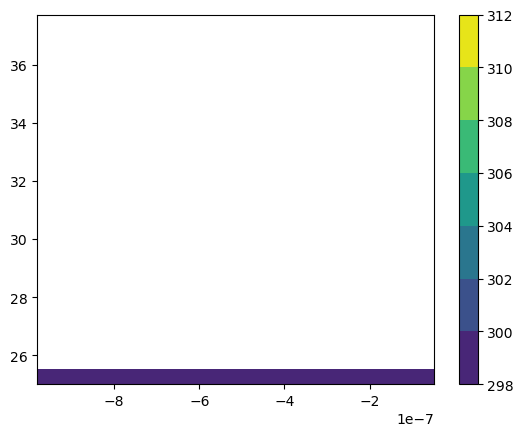

<Axes: >

In [39]:
# Extract data for 2D plotting
solution = sim.solution
# print(solution)
x = pybamm.Array(solution["Negative electrode potential [V]"].entries)
y = pybamm.Array(solution['Negative current collector temperature [C]'].entries)
z = pybamm.Array(np.transpose(solution['Negative electrode temperature [K]'].entries))



# Plot the 2D data

print (x,y,z)

pybamm.plot2D(x,y,z, show_plot=True)

Now if we had some experimental data we can try match this to the data to see how accurate it is.